# Проверка гипотез сервиса аренды самокатов GoFast

## Описание проекта

Сервис аренды самокатов GoFast работает в нескольких городах России и предлагает
пользователям либо бесплатный тариф (`free`), либо платную подписку `ultra` с
абонентской платой и сниженной ценой минуты. Нужно проверить несколько
продуктовых гипотез о поведении подписчиков, которые помогут понять, окупает ли
себя подписка для бизнеса.

**План работы:**
1. Загрузить и изучить три таблицы: пользователи, поездки, тарифы
2. Предобработка: дубликаты, типы данных, служебные признаки
3. Разведочный анализ: города, возраст, дистанция и длительность поездок, поиск аномалий
4. Объединить таблицы и посчитать помесячную выручку по каждому пользователю
5. Проверить 4 гипотезы: для каждой — H0/H1, выбор критерия с обоснованием, вывод

**Уровень значимости** для всех проверок гипотез — `alpha = 0.05`.

## Описание данных

- `users_go.csv` — пользователи: `user_id`, `name`, `age`, `city`, `subscription_type` (`free`/`ultra`)
- `rides_go.csv` — поездки: `user_id`, `distance` (метры), `duration` (минуты), `date`
- `subscriptions_go.csv` — тарифы: `subscription_type`, `minute_price`, `start_ride_price`, `subscription_fee`

Данные предоставлены курсом и не публикуются.

## Подготовка к проекту

### Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

ALPHA = 0.05

## Загрузка данных и первичное ознакомление

In [2]:
def inspect_table(df, name):
    print(f"=== {name} ===")
    print(f"Размер: {df.shape}")
    display(df.head())
    df.info()
    print(f"Полных дубликатов: {df.duplicated().sum()}")
    print("=" * 100)

users = pd.read_csv('data/users_go.csv')
rides = pd.read_csv('data/rides_go.csv')
subscriptions = pd.read_csv('data/subscriptions_go.csv')

inspect_table(users, 'users')
inspect_table(rides, 'rides')
inspect_table(subscriptions, 'subscriptions')

=== users ===
Размер: (1565, 5)


,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


<class 'pandas.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   user_id            1565 non-null   int64
 1   name               1565 non-null   str  
 2   age                1565 non-null   int64
 3   city               1565 non-null   str  
 4   subscription_type  1565 non-null   str  
dtypes: int64(2), str(3)
memory usage: 61.3 KB
Полных дубликатов: 31
=== rides ===
Размер: (18068, 4)


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


<class 'pandas.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  str    
dtypes: float64(2), int64(1), str(1)
memory usage: 564.8 KB
Полных дубликатов: 0
=== subscriptions ===
Размер: (2, 4)


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   subscription_type  2 non-null      str  
 1   minute_price       2 non-null      int64
 2   start_ride_price   2 non-null      int64
 3   subscription_fee   2 non-null      int64
dtypes: int64(3), str(1)
memory usage: 196.0 bytes
Полных дубликатов: 0


### Вывод

Пропусков нет ни в одной таблице. В `users` — 31 полный дубликат строки, в `rides`
и `subscriptions` дубликатов нет. Типы данных в порядке, кроме `date` в `rides` —
это строка, а не дата.

## Предобработка

### Дубликаты пользователей

In [3]:
dupe_rows = users[users.duplicated(keep=False)].sort_values('user_id')
dupe_rows.head(6)

,user_id,name,age,city,subscription_type
15,16,Амалия,27,Краснодар,ultra
1535,16,Амалия,27,Краснодар,ultra
1539,43,Стефания,22,Омск,ultra
42,43,Стефания,22,Омск,ultra
46,47,Юрий,28,Тюмень,ultra
1563,47,Юрий,28,Тюмень,ultra


Каждый дубликат — точная копия другой строки, а не похожая запись: дублирующая
строка всегда находится в конце датафрейма, и её `user_id` совпадает с `user_id`
оригинала. Похоже на баг выгрузки (например, повторное сохранение части строк),
а не на два разных человека с одинаковыми данными случайно. Сообщать о находке
разработчикам не наша задача в рамках проекта — просто уберём дубликаты.

In [4]:
users = users.drop_duplicates().reset_index(drop=True)
print(f"Пользователей после удаления дубликатов: {len(users)}")

Пользователей после удаления дубликатов: 1534


### Приведение типов

In [5]:
rides['date'] = pd.to_datetime(rides['date'])
rides['month'] = rides['date'].dt.month

## Разведочный анализ

### Пользователи: города, тариф, возраст

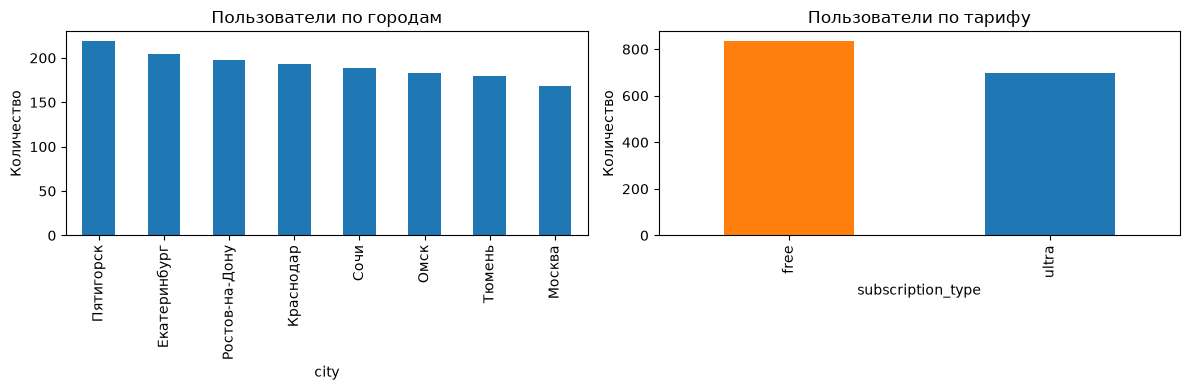

city
Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: count, dtype: int64

subscription_type
free     835
ultra    699
Name: count, dtype: int64
Доля подписчиков ultra: 45.6%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
users['city'].value_counts().plot.bar(ax=axes[0])
axes[0].set_title('Пользователи по городам')
axes[0].set_ylabel('Количество')

users['subscription_type'].value_counts().plot.bar(ax=axes[1], color=['C1', 'C0'])
axes[1].set_title('Пользователи по тарифу')
axes[1].set_ylabel('Количество')
plt.tight_layout()
plt.show()

print(users['city'].value_counts())
print()
print(users['subscription_type'].value_counts())
print(f"Доля подписчиков ultra: {(users['subscription_type']=='ultra').mean():.1%}")

Пользователи распределены по 8 городам примерно поровну (от 168 до 219 на город) —
похоже, компания заходит на новые рынки стандартными пачками самокатов, а не
органическим ростом. Подписчиков `ultra` — 46% базы, `free` — 54%.

### Возраст пользователей

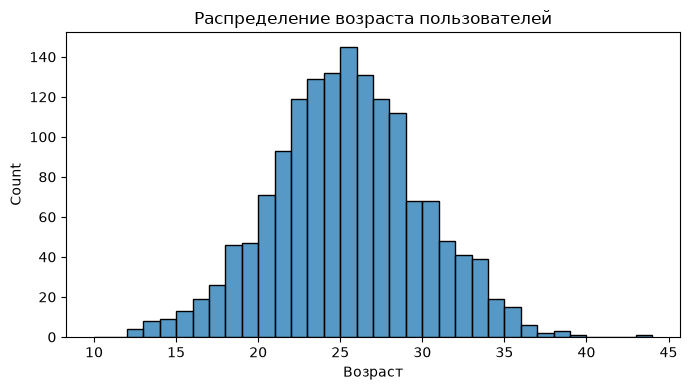

count    1534.000000
mean       24.903520
std         4.572367
min        12.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

Пользователей младше 18 лет: 79 (5.1%)


In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(users['age'], bins=range(10, 45), ax=ax)
ax.set_title('Распределение возраста пользователей')
ax.set_xlabel('Возраст')
plt.tight_layout()
plt.show()

print(users['age'].describe())
underage = users[users['age'] < 18]
print(f"\nПользователей младше 18 лет: {len(underage)} ({len(underage)/len(users):.1%})")

Возраст распределён похоже на нормальное распределение с центром около 25 лет,
но минимум — 12 лет: 79 пользователей (5.1% базы) младше 18. Аренда самокатов
обычно ограничена по возрасту (в большинстве городов — с 18, у отдельных
операторов с 14 лет при регистрации через родителя). Это не техническая
аномалия вроде дублей — записи выглядят валидными данными, — но продуктовый
риск, который стоит передать юридической/продуктовой команде: либо в
регистрации нет проверки возраста, либо в данные попали тестовые аккаунты.
Т.к. это не искажает саму механику поездок, из дальнейшего анализа эти строки
не убираем — но фиксируем находку явно, а не молчим о ней.

### Поездки: дистанция и длительность

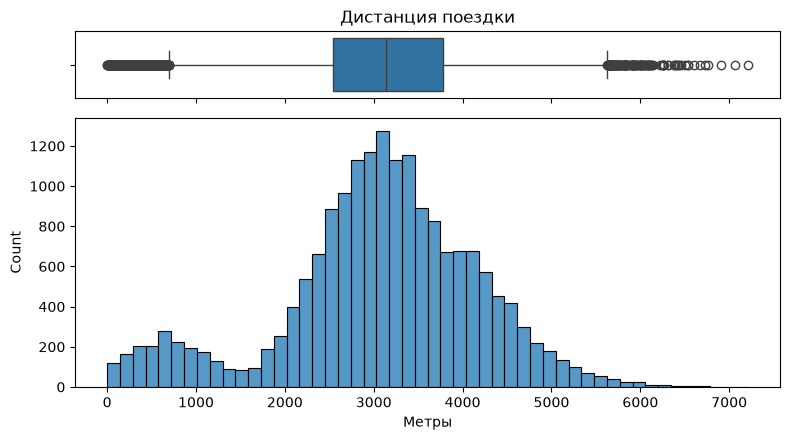

count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
25%       2543.226360
50%       3133.609994
75%       3776.222735
max       7211.007745
Name: distance, dtype: float64


In [8]:
def plot_hist_box(series, title, xlabel):
    fig, (ax_box, ax_hist) = plt.subplots(
        2, 1, figsize=(8, 4.5), gridspec_kw={'height_ratios': (0.2, 0.8)}, sharex=True
    )
    sns.boxplot(x=series, ax=ax_box)
    sns.histplot(series, bins=50, ax=ax_hist)
    ax_box.set(xlabel='', title=title)
    ax_hist.set_xlabel(xlabel)
    plt.tight_layout()
    plt.show()

plot_hist_box(rides['distance'], 'Дистанция поездки', 'Метры')
print(rides['distance'].describe())

Два пика на гистограмме дистанции — около 700 м и около 3 км, оба в пределах разумного диапазона для городской поездки на самокате, без явных выбросов.

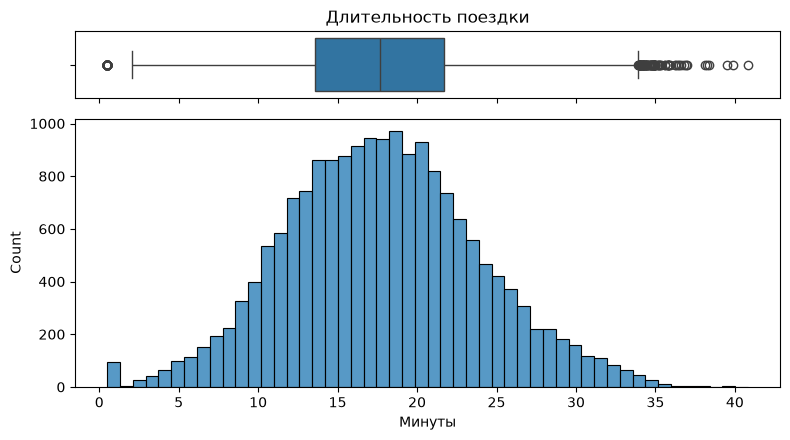

count    18068.000000
mean        17.805011
std          6.091051
min          0.500000
25%         13.597563
50%         17.678395
75%         21.724800
max         40.823963
Name: duration, dtype: float64


In [9]:
plot_hist_box(rides['duration'], 'Длительность поездки', 'Минуты')
print(rides['duration'].describe())

### Аномалия скорости

In [10]:
rides['avg_speed'] = rides['distance'] / rides['duration']

# Реальные самокаты ограничены по скорости конкурентами рынка на уровне ~25 км/ч
# (~417 м/мин). Найдём поездки, где средняя скорость намного выше физически возможной.
speed_anomaly = rides[rides['avg_speed'] > 1000]
print(f"Поездок с аномальной скоростью: {len(speed_anomaly)}")
print(speed_anomaly['duration'].value_counts())
print(speed_anomaly['avg_speed'].describe())

Поездок с аномальной скоростью: 95
duration
0.5    95
Name: count, dtype: int64
count       95.000000
mean     10226.353097
std       1316.508209
min       8060.616017
25%       9223.021640
50%      10105.538822
75%      10976.918198
max      14422.015489
Name: avg_speed, dtype: float64


Все 95 аномальных поездок имеют длительность ровно 0.5 минуты — не случайный
разброс, а фиксированное значение. Похоже на баг секундомера в приложении
(например, таймер не запустился и записал минимальное значение), а не на ошибку
в дистанции. Эти строки не выбрасываем: расстояние в них выглядит достоверным
и участвует в выручке за поездку, а длительность (и, соответственно,
скорость) — нет. Стоит сообщить о находке в отдельном разделе выводов.

## Объединение таблиц и расчёт выручки

In [11]:
df = rides.merge(users, on='user_id').merge(subscriptions, on='subscription_type')
print(df.shape)
df.head()

(18068, 13)


,user_id,distance,duration,date,month,avg_speed,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,4409.919140,25.599769,2021-01-01,1,172.264021,Кира,22,Тюмень,ultra,6,0,199
1,1,2617.592153,15.816871,2021-01-18,1,165.493673,Кира,22,Тюмень,ultra,6,0,199
2,1,754.159807,6.232113,2021-04-20,4,121.011887,Кира,22,Тюмень,ultra,6,0,199
3,1,2694.783254,18.511000,2021-08-11,8,145.577402,Кира,22,Тюмень,ultra,6,0,199
4,1,4028.687306,26.265803,2021-08-28,8,153.381465,Кира,22,Тюмень,ultra,6,0,199


Посчитаем выручку по каждому пользователю за каждый месяц: абонентская плата
(если есть) + стоимость минут + стоимость стартов поездок. Явно перечисляем
агрегации списком, а не множеством `{...}` — порядок элементов в `set` не
гарантирован, и была версия этого кода, где порядок совпал случайно.

Выручка за весь период: 3,813,029 руб.


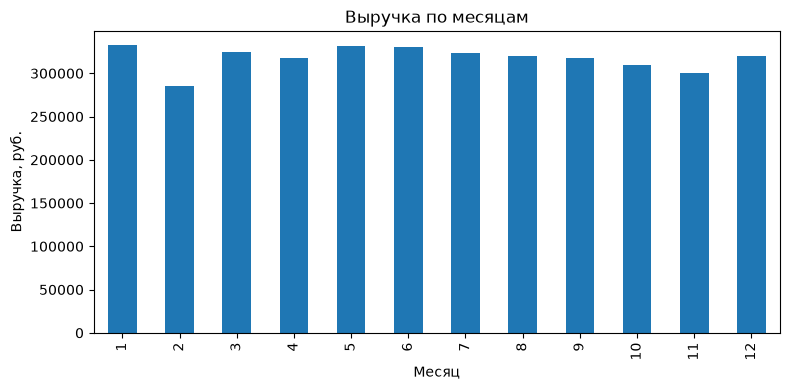

In [12]:
monthly = df.groupby(['user_id', 'month'], as_index=False).agg(
    rides_count=('distance', 'count'),
    distance=('distance', 'sum'),
    duration=('duration', 'sum'),
    minute_price=('minute_price', 'min'),
    start_ride_price=('start_ride_price', 'min'),
    subscription_fee=('subscription_fee', 'min'),
)
monthly['revenue'] = (
    monthly['duration'] * monthly['minute_price']
    + monthly['rides_count'] * monthly['start_ride_price']
    + monthly['subscription_fee']
)

print(f"Выручка за весь период: {monthly['revenue'].sum():,.0f} руб.")

monthly_totals = monthly.groupby('month')['revenue'].sum()
fig, ax = plt.subplots(figsize=(8, 4))
monthly_totals.plot.bar(ax=ax)
ax.set_xlabel('Месяц')
ax.set_ylabel('Выручка, руб.')
ax.set_title('Выручка по месяцам')
plt.tight_layout()
plt.show()

## Проверка гипотез

Для каждой гипотезы: формулируем H0/H1, выбираем критерий, проверяем
предпосылки (тестом Левене на равенство дисперсий — от этого зависит, какую
версию t-теста использовать), считаем статистику и делаем вывод при
`alpha = 0.05`.

### Гипотеза 1: подписчики ездят дольше за одну поездку

- **H0:** средняя длительность поездки одинакова у пользователей `ultra` и `free`
- **H1:** средняя длительность поездки у `ultra` выше, чем у `free`

Односторонний тест, т.к. вопрос направленный: интересует именно «дольше», а не «отличается».

In [13]:
ultra_rides = df[df['subscription_type'] == 'ultra']
free_rides = df[df['subscription_type'] == 'free']

print(f"n(ultra) = {len(ultra_rides)}, n(free) = {len(free_rides)}")
print(f"Среднее ultra: {ultra_rides['duration'].mean():.2f} мин, std: {ultra_rides['duration'].std():.2f}")
print(f"Среднее free:  {free_rides['duration'].mean():.2f} мин, std: {free_rides['duration'].std():.2f}")

levene_dur = stats.levene(ultra_rides['duration'], free_rides['duration'])
print(f"\nТест Левене на равенство дисперсий: p-value = {levene_dur.pvalue:.2e}")

n(ultra) = 6500, n(free) = 11568
Среднее ultra: 18.54 мин, std: 5.57
Среднее free:  17.39 мин, std: 6.33

Тест Левене на равенство дисперсий: p-value = 3.25e-31


Тест Левене отвергает равенство дисперсий (p ≪ 0.05) — используем t-тест Уэлча
(`equal_var=False`), а не обычный, который это равенство предполагает.

In [14]:
result_1 = stats.ttest_ind(
    ultra_rides['duration'], free_rides['duration'],
    alternative='greater', equal_var=False
)
print(f"t-статистика = {result_1.statistic:.2f}, p-value = {result_1.pvalue:.2e}")
print("Вывод:", "отвергаем H0" if result_1.pvalue < ALPHA else "не отвергаем H0")

t-статистика = 12.68, p-value = 5.68e-37
Вывод: отвергаем H0


p-value практически равен нулю — отвергаем H0. Подписчики `ultra` статистически значимо ездят дольше за одну поездку, чем пользователи `free`.

### Гипотеза 2: среднее расстояние поездки подписчиков не превышает 3130 метров

3130 метров — расстояние, после которого, по оценке инженеров сервиса,
ускоренный износ самоката становится статистически заметным. Хотим понять,
укладываются ли подписчики `ultra` в этот бюджет в среднем.

- **H0:** среднее расстояние поездки `ultra` ≥ 3130 м
- **H1:** среднее расстояние поездки `ultra` < 3130 м

Выборочное среднее (см. ниже) уже ниже порога, поэтому тест не столько проверяет
неожиданную гипотезу, сколько оценивает, достаточно ли уверенно оно ниже —
с учётом разброса и размера выборки.

In [15]:
ultra_distance = ultra_rides['distance']
print(f"n = {len(ultra_distance)}")
print(f"Среднее: {ultra_distance.mean():.1f} м, медиана: {ultra_distance.median():.1f} м, std: {ultra_distance.std():.1f} м")

result_2 = stats.ttest_1samp(ultra_distance, 3130, alternative='less')
print(f"\nt-статистика = {result_2.statistic:.2f}, p-value = {result_2.pvalue:.3f}")
print("Вывод:", "отвергаем H0" if result_2.pvalue < ALPHA else "не отвергаем H0")

n = 6500
Среднее: 3115.4 м, медиана: 3148.6 м, std: 836.9 м

t-статистика = -1.40, p-value = 0.080
Вывод: не отвергаем H0


p-value = 0.080 — выше 0.05, H0 не отвергаем. **Это не значит, что H0 верна** —
значит лишь, что при выборке в 6500 поездок разницы между средним (3115 м) и
порогом (3130 м) недостаточно, чтобы уверенно исключить, что истинное среднее
равно или превышает порог. Среднее расстояние держится очень близко к границе
экономичного использования — с точки зрения бизнеса это повод для мониторинга,
а не повод для спокойствия.

### Гипотеза 3: помесячная выручка от подписчиков выше, чем от пользователей без подписки

- **H0:** средняя помесячная выручка одного пользователя одинакова у `ultra` и `free`
- **H1:** средняя помесячная выручка одного пользователя у `ultra` выше

Единица наблюдения — **пользователь**, а не пользователь-месяц: один и тот же
человек катается из месяца в месяц не независимо от самого себя, и если
взять все его помесячные записи как отдельные наблюдения, тест увидит куда
больше «данных», чем на самом деле независимой информации. Поэтому сначала
агрегируем таблицу `monthly` до одной строки на пользователя — его собственной
средней выручки в месяц, — и уже по ней сравниваем группы.

In [16]:
per_user = monthly.merge(users[['user_id', 'subscription_type']], on='user_id').groupby(
    ['user_id', 'subscription_type'], as_index=False
)['revenue'].mean()

ultra_users = per_user[per_user['subscription_type'] == 'ultra']['revenue']
free_users = per_user[per_user['subscription_type'] == 'free']['revenue']

print(f"n(ultra) = {len(ultra_users)} пользователей, n(free) = {len(free_users)} пользователей")
print(f"Средняя выручка ultra: {ultra_users.mean():.1f} руб./мес, std: {ultra_users.std():.1f}")
print(f"Средняя выручка free:  {free_users.mean():.1f} руб./мес, std: {free_users.std():.1f}")

levene_rev = stats.levene(ultra_users, free_users)
print(f"\nТест Левене: p-value = {levene_rev.pvalue:.2e}")

n(ultra) = 699 пользователей, n(free) = 835 пользователей
Средняя выручка ultra: 358.8 руб./мес, std: 37.1
Средняя выручка free:  321.7 руб./мес, std: 63.2

Тест Левене: p-value = 8.24e-37


Дисперсии снова значимо различаются — используем t-тест Уэлча.

In [17]:
result_3 = stats.ttest_ind(ultra_users, free_users, alternative='greater', equal_var=False)
print(f"t-статистика = {result_3.statistic:.2f}, p-value = {result_3.pvalue:.2e}")
print("Вывод:", "отвергаем H0" if result_3.pvalue < ALPHA else "не отвергаем H0")

t-статистика = 14.28, p-value = 1.45e-43
Вывод: отвергаем H0


p-value практически равен нулю — отвергаем H0. Один подписчик `ultra` в среднем
приносит больше выручки в месяц, чем один пользователь `free`, даже после
корректной агрегации на уровне пользователя (699 против 835 человек, а не
тысячи псевдонезависимых пользователь-месяцев).

### Гипотеза 4 (гипотетическая): снизилось ли число обращений в техподдержку после обновления сервера

Данных для этой проверки нет — вопрос теоретический: **каким тестом** её
стоило бы проверять.

Если для одних и тех же пользователей есть количество обращений «до» и
«после» обновления — выборки зависимые (парные), нужен `scipy.stats.ttest_rel`.
Проверяем H1: обращений стало **меньше** после обновления, то есть среднее
«до» больше среднего «после»:

```python
scipy.stats.ttest_rel(before, after, alternative='greater')
```

`alternative='greater'` здесь означает «среднее первого аргumента (`before`)
больше среднего второго (`after`)» — именно это и утверждает гипотеза о
снижении числа обращений.

Если пользователи, обращавшиеся в поддержку до обновления, и те, кто обращался
после, не пересекаются (например, разные волны опроса без привязки к
конкретным людям) — выборки независимые, и нужен `scipy.stats.ttest_ind` с тем
же `alternative='greater'`, предварительно проверив тестом Левене, нужен ли
`equal_var=False`.

## Выводы

**Данные.** 1534 уникальных пользователя (после удаления 31 полного дубликата
строки — судя по структуре, баг выгрузки, а не совпадение), 18068 поездок.
46% пользователей — подписчики `ultra`. Найдены две аномалии: 95 поездок с
длительностью ровно 0.5 минуты (похоже на баг секундомера, оставлены в данных)
и 79 пользователей младше 18 лет (5.1% базы — стоит проверить проверку
возраста при регистрации).

**Выручка.** Суммарно сервис заработал за период около 3.81 млн рублей.

**Гипотезы** (alpha = 0.05, во всех тестах предварительно проверено равенство
дисперсий тестом Левене — везде оно нарушено, поэтому везде использован
t-тест Уэлча):

1. Подписчики `ultra` статистически значимо ездят дольше за одну поездку, чем
   пользователи `free` (p ≈ 1e-36).
2. Среднее расстояние поездки `ultra` (3115 м) статистически неотличимо от
   порога 3130 м (p = 0.080) — данных недостаточно, чтобы уверенно сказать,
   что подписчики укладываются в порог экономичного износа самоката. Требует
   дальнейшего мониторинга, а не считается закрытым вопросом.
3. Один подписчик `ultra` в среднем приносит больше выручки в месяц, чем один
   пользователь `free` (p ≈ 1e-42, после корректной агрегации на уровне
   пользователя, а не пользователь-месяца).
4. (Гипотетическая) Для проверки снижения числа обращений в техподдержку
   нужен `ttest_rel` для зависимых выборок или `ttest_ind` для независимых —
   в обоих случаях с `alternative='greater'` при сравнении «до» и «после».

**Бизнес-вывод:** подписка `ultra` работает так, как задумано — подписчики
катаются дольше и приносят больше денег в месяц. Единственный неоднозначный
результат — расстояние поездки против порога износа: 3115 м против 3130 м
недостаточно разошлись, чтобы сделать твёрдый вывод, и это стоит отслеживать
дальше, а не считать вопрос закрытым.

## Что бы сделал иначе

- В оригинальной версии агрегация выручки по месяцу считалась через
  `aggfunc={'distance': {'count', 'sum'}}` — питоновское множество, порядок
  элементов которого не гарантирован; переименование колонок по позиции после
  такой агрегации могло однажды тихо перепутать местами количество поездок и
  суммарную дистанцию. Заменил на именованные агрегации (`pd.NamedAgg`-стиль
  через `.agg(name=(col, func))`), где колонка и её смысл связаны явно, а не
  порядком.
- Гипотеза о выручке в исходной версии сравнивала пользователь-месяцы, а не
  пользователей — один активный подписчик мог внести 12 «независимых»
  наблюдений в выборку из полутора тысяч. Агрегация до одного значения на
  пользователя не изменила вывод (p-value осталось исчезающе малым), но
  сделала его статистически корректным, а не просто «сработавшим».
- Возрастную аномалию (79 несовершеннолетних пользователей) в исходной версии
  заметили на графике, но не довели до вывода. Здесь она явно зафиксирована
  как продуктовый риск, а не только как наблюдение на гистограмме.